Health Cost PRediction - Exploratory Data Analysis

## Objective
Understand patterns in healthcare costs and identify key drivers

In [4]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/insurance.csv')
print(f'dataset shape: {df.shape}')
df.head()

dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
print('missing values')
df.isnull().sum()

missing values


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

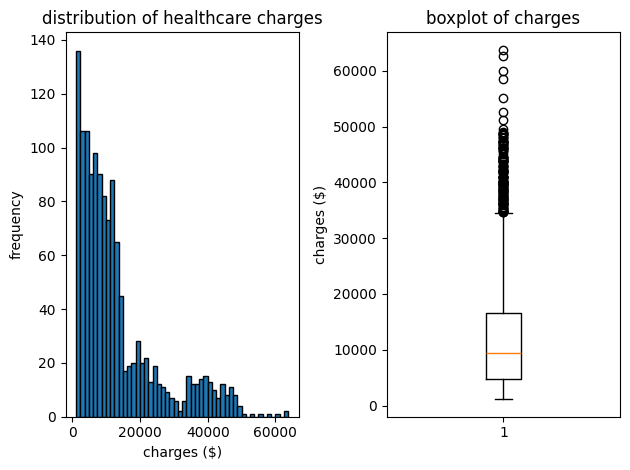

mean charge: $13,270.42
median charge: $9,382.03
skewness: $1.52


In [ ]:
# distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['charges'], bins=50, edgecolor='black')
plt.xlabel('charges ($)')
plt.ylabel('frequency')
plt.title('distribution of healthcare charges')

plt.subplot(1, 2, 2)
plt.boxplot(df['charges'])
plt.ylabel('charges ($)')
plt.title('boxplot of charges')
plt.tight_layout()
plt.show()

print(f'mean charge: ${df['charges'].mean():,.2f}')
print(f'median charge: ${df['charges'].median():,.2f}')
print(f'skewness: ${df['charges'].skew():,.2f}')

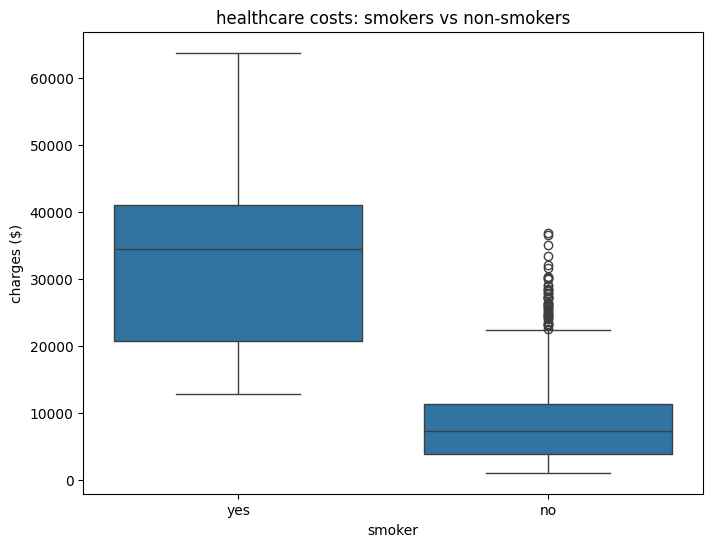

average cost for non-smoker: $8,434.27
average cost for smoker: $32,050.23
difference: $23,615.96


In [17]:
# smoker impact
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('healthcare costs: smokers vs non-smokers')
plt.ylabel('charges ($)')
plt.show()

smoker_cost = df.groupby('smoker')['charges'].mean()
print(f'average cost for non-smoker: ${smoker_cost['no']:,.2f}')
print(f'average cost for smoker: ${smoker_cost['yes']:,.2f}')
print(f'difference: ${smoker_cost['yes'] - smoker_cost['no']:,.2f}')

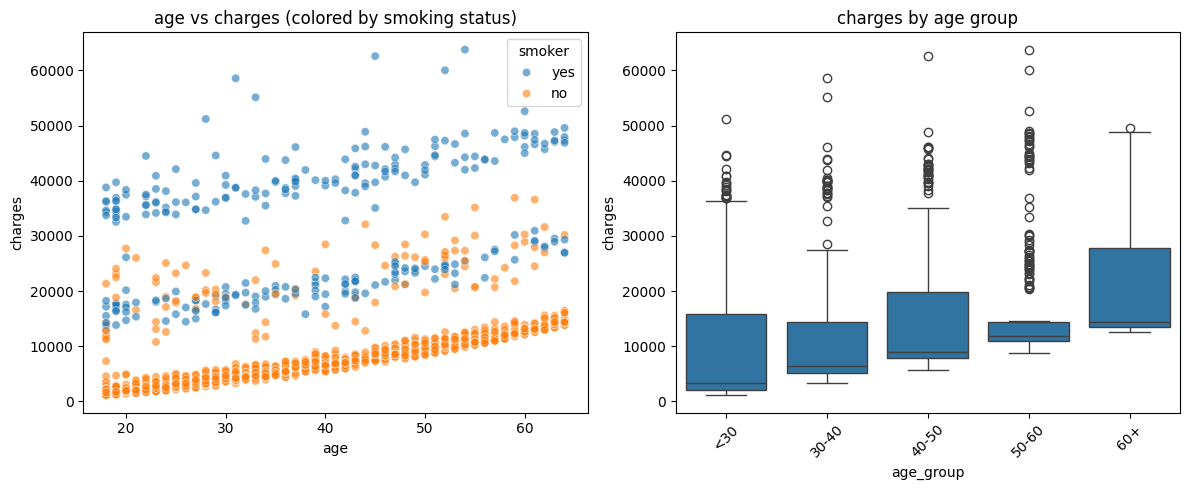

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('age vs charges (colored by smoking status)')

plt.subplot(1, 2, 2)
df['age_group'] = pd.cut(df['age'], bins=[0,30, 40, 50, 60, 100],
                      labels=['<30', '30-40', '40-50', '50-60', '60+']
                  )
sns.boxplot(x='age_group', y='charges', data=df)
plt.title('charges by age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


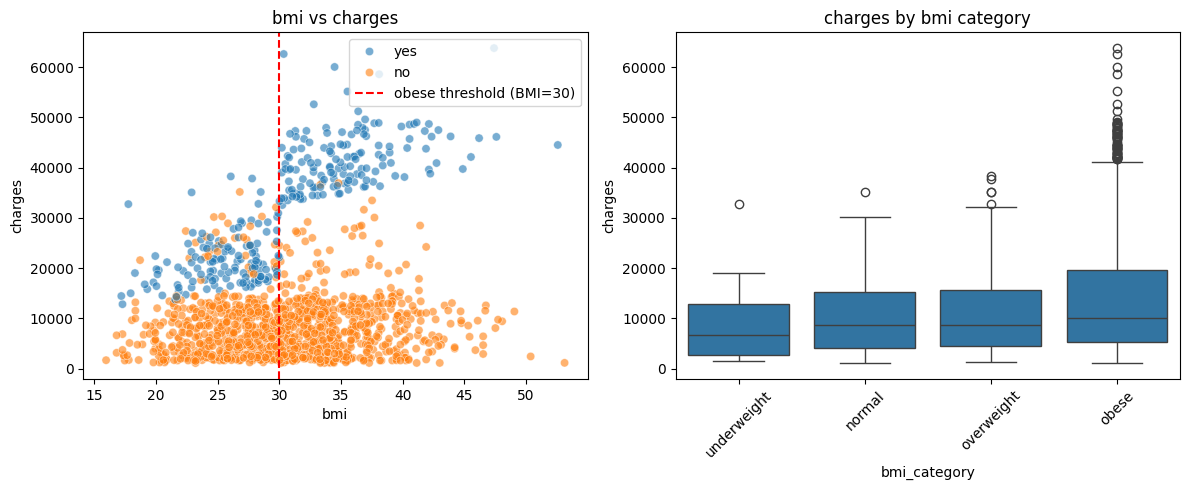

In [23]:
# bmi impact
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)
plt.axvline(x=30, color='red', linestyle='--', label='obese threshold (BMI=30)')
plt.legend()
plt.title('bmi vs charges')


plt.subplot(1, 2, 2)
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 50],
                         labels=['underweight', 'normal', 'overweight', 'obese']
                     )
sns.boxplot(x='bmi_category', y='charges', data=df)
plt.title('charges by bmi category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

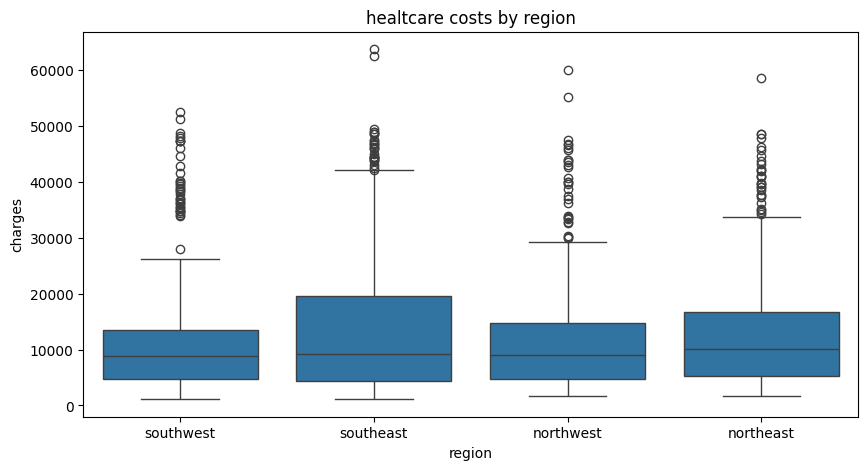

average costs by region:
region
southwest    12346.937377
northwest    12417.575374
northeast    13406.384516
southeast    14735.411438
Name: charges, dtype: float64


In [24]:
# region impact
plt.figure(figsize=(10, 5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('healtcare costs by region')
plt.show()

region_costs = df.groupby('region')['charges'].mean().sort_values()
print('average costs by region:')
print(region_costs)

In [ ]:
# children impact
plt.figure(figsize=8, 5)
